# **Clustering Prestador y Tareas Unificado Clásico KMeans**

# 1 - Librerías

In [163]:
from google.cloud import bigquery
import bigframes.pandas as bpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import re
from bigframes.ml.preprocessing import StandardScaler
from bigframes.ml.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


# 2 - Carga de Datos

In [164]:
# Objecto cliente

client = bigquery.Client()

In [165]:
# sql_engine: bigquery
# output_variable: tareas_df
# output_mode: table
# start _sql
_sql = """
SELECT * FROM proyecto-sura-clustering-2026.sura_clustering_cleaned.tareas_programadas;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
tareas_df = _bqsqlcell.run(_sql)
tareas_df

,NMCONSECUTIVO_ORDEN,NMCONSECUTIVO_PLAN,NMACTIVIDAD,NMVERSION,DNI_DISTRIBUIDOR,NOMBRE_DISTRIBUIDOR,DNI_PRESTADOR,NOMBRE_PRESTADOR,TIPO_DE_ASESOR,DNI_EMPRESA,...,FEAPROBACION_INFORME,FERECHAZO_INFORME,SNAPROBADO_AUTOMATICO,SNPARCIAL,OBSERVACIONES_PROGRAMACION,CORREO_CONTACTO,NOMBRE_CONTACTO,DSCELULAR_CONTACTO,FECHA_CARGA,FLAG_CANTIDAD_EJECUTADA_NEGATIVA
0,9506484,46553,460,13,6f100ce439,f6d0860470,b21280086a,5f83feaa54,ASESOR LINEA DE ATENCION,93a08f0a4a,...,<NA>,<NA>,<NA>,<NA>,<NA>,9d023bf915,28390e836e,<NA>,2026-01-06,False
1,8560565,563286,2333,6,c6c57ab754,565dd4eef6,a29b0d2a33,e3024e438a,ASESOR EN RIESGOS,f44bdf319e,...,2025-02-22,<NA>,True,False,<NA>,37c14c5bdf,f33b103435,cb8917ac40,2026-01-06,False
2,9573385,49717,164,15,65689d0bb1,e0366ee3ab,65689d0bb1,a191b73285,ASESOR EN PREVENCIÓN,6ed334fa2b,...,<NA>,<NA>,<NA>,<NA>,<NA>,1b0731c2ab,f70d303145,254fd5b9ce,2026-01-06,False
3,9573389,49717,163,15,0f865f8395,cc1752cedb,0f865f8395,55590d12f2,ASESOR EN PREVENCIÓN,6ed334fa2b,...,<NA>,<NA>,<NA>,<NA>,<NA>,1b0731c2ab,5e4ce4a258,5ab9c681bb,2026-01-06,False
4,9181494,194022,109,8,6f100ce439,f6d0860470,534962e443,7c0092de5c,PROYECTOS,951a262802,...,2025-08-09,<NA>,True,False,<NA>,<NA>,<NA>,<NA>,2026-01-06,False
5,8602271,595127,80,7,6f100ce439,f6d0860470,0a81a8afec,c6ddd191a2,ASESOR EN RIESGOS,434870e007,...,<NA>,<NA>,<NA>,<NA>,<NA>,5834bdc18f,838f84421a,<NA>,2026-01-06,False
6,8650723,24138,2795,3,1edd4fc7b9,3951540d70,1edd4fc7b9,0de4fc7094,ASESOR EN PREVENCIÓN,5b74e54333,...,<NA>,<NA>,<NA>,<NA>,<NA>,da45427137,34d8901647,10b05915ce,2026-01-06,False
7,9237645,52252,63,15,6f100ce439,f6d0860470,9237b92937,4bd58712e1,ASESOR EN PREVENCIÓN,0f8be0a77d,...,<NA>,<NA>,<NA>,<NA>,POR TIEMPO,4ca43d9dcd,c5c57ee217,<NA>,2026-01-06,False
8,9263231,225287,74,9,6f100ce439,f6d0860470,69ba73988b,f50d5953e0,ASESOR EN PREVENCIÓN,46337a5654,...,2025-08-09,<NA>,True,True,<NA>,<NA>,<NA>,<NA>,2026-01-06,False
9,8990741,563286,3786,6,6f100ce439,f6d0860470,c7f365e8e9,b6d51a1cbc,ASESOR EN RIESGOS,f44bdf319e,...,<NA>,<NA>,<NA>,<NA>,<NA>,37c14c5bdf,4458cbddcd,<NA>,2026-01-06,False


In [166]:
# sql_engine: bigquery
# output_variable: prestadores_df
# output_mode: table
# start _sql
_sql = """
SELECT * FROM proyecto-sura-clustering-2026.sura_clustering_cleaned.tareas_prestador;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
prestadores_df = _bqsqlcell.run(_sql)
prestadores_df

,DNI_PRESTADOR,NOMBRE_PRESTADOR,CDOFICINA,DSOFICINA,DNI_DISTRIBUIDOR,NOMBRE_DISTRIBUIDOR,CDPRODUCTO,DSPRODUCTO,CDBLOQUE,DSBLOQUE,...,SNCONTROLAR_HORAS_MES,PERIODO_CONSULTA_CAPACIDAD,CDMUNICIPIO_ORIGEN_OC,DSMUNICIPIO_ORIGEN_OC,CAPACIDAD,FEC_INI_COS_TAR,FEC_FIN_COS_TAR,FECHA_CARGA,_RED_ORIGEN,FLAG_CAPACIDAD_CERO
0,38c26e396f,b70140496b,61,OFICINA MANIZALES,f54241414a,fccb4b900f,129,129-TRABAJO SEGURO EN ESPACIOS CONFINADOS,14,HERRAMIENTAS PARA EL DESEMPEÑO HUMANO,...,True,202603,4192,MANIZALES,110.0,<NA>,3000-12-30,2026-03-09,Red_otras_ofic,False
1,3064b2c30b,570b38f125,21,OFICINA MEDELLIN,73ab9ee746,0a26f6c589,171,171-PREVENCIÓN DE CAÍDAS A NIVEL,14,HERRAMIENTAS PARA EL DESEMPEÑO HUMANO,...,True,202603,4292,MEDELLIN,220.0,<NA>,3000-12-30,2026-03-09,Red_med&Cali,False
2,ea031fbcd1,0ff1bbe480,21,OFICINA MEDELLIN,7de181f880,adb5d53ae4,124,124-GESTION DE ORDEN Y ASEO,1,EDUCACIÓN,...,True,202603,823,CALDAS,160.0,<NA>,3000-12-30,2026-03-09,Red_med&Cali,False
3,cc858b0275,b95fdf84f0,53,OFICINA BUCARAMANGA,5a47e5a9f3,75f42ab95a,11,SISTEMA DE GESTION EN SST,6,GENERAL,...,True,202603,1566,DUITAMA,200.0,<NA>,3000-12-30,2026-03-09,Red_otras_ofic,False
4,2aec78e6cf,b63ee82259,41,OFICINA BOGOTA,972889b47e,f0bbef265d,68,SOBREESFUERZOS (ATEL),8,GENERAL,...,True,202603,586,BOGOTA,220.0,<NA>,3000-12-30,2026-03-09,Red_Bogota,False
5,8d268b154f,a4eda03bb2,61,OFICINA MANIZALES,f54241414a,fccb4b900f,171,171-PREVENCIÓN DE CAÍDAS A NIVEL,15,LECTURA DEL ENTORNO,...,True,202603,7172,VILLAMARIA,0.0,<NA>,3000-12-30,2026-03-09,Red_otras_ofic,True
6,3f062f4dad,577e3a237d,51,OFICINA BARRANQUILLA,81dbf0431e,050cde9fa6,139,139-PVE Y ACCIONES PARA LA PREVENCIÓN DE LOS E...,15,LECTURA DEL ENTORNO,...,True,202603,427,BARRANQUILLA,220.0,<NA>,3000-12-30,2026-03-09,Red_otras_ofic,False
7,d12b4e320f,254b4ff6d8,21,OFICINA MEDELLIN,d12b4e320f,d48db8b127,142,142-PVE Y ACCIONES PARA LA PREVENCION DE LA HI...,62,HERRAMIENTAS PARA EL DESEMPEÑO HUMANO-EXAMEN,...,True,202603,4292,MEDELLIN,180.0,<NA>,2025-09-18,2026-03-09,Red_med&Cali,False
8,76a7baacd3,a6ab0d6274,21,OFICINA MEDELLIN,30b439c96a,b0a41ed6bb,170,170-SISTEMA DE GESTIÓN EN SST,16,SISTEMAS DE INFORMACIÓN Y DESEMPEÑO DEL SG-SST,...,True,202603,4292,MEDELLIN,1.0,<NA>,3000-12-30,2026-03-09,Red_med&Cali,False
9,5937f0e349,5d6d11daf0,52,OFICINA CARTAGENA,3768dfecf0,1ad25959d2,170,170-SISTEMA DE GESTIÓN EN SST,1,EDUCACIÓN,...,True,202603,1018,CARTAGENA DE INDIAS,220.0,<NA>,3000-12-30,2026-03-09,Red_otras_ofic,False


# 3 - Limpieza Dataset Tareas

In [167]:
# Eliminar columnas con umbral por encima de 10%

umbral = 0.1
cols_eliminar_tareas = []

for col in tareas_df.columns:

  if tareas_df[col].isnull().sum() / len(tareas_df) > umbral:

    cols_eliminar_tareas.append(col)

print(cols_eliminar_tareas)
print(len(cols_eliminar_tareas))

tareas_df = tareas_df.drop(cols_eliminar_tareas, axis = 1)

['FEINGRESO_CUMPLIMIENTO', 'DURACION', 'NMASISTENTES', 'DNI_INGRESA_CUMPLIMIENTO', 'FECANCELACION', 'MOTIVO_CANCELACION', 'SNCANCELA_EMPRESA', 'DNI_CANCELA_PROGRAMACION', 'NOMBRE_CANCELA_PROGRAMACION', 'FEENVIO_INFORME', 'DNI_ENVIO_INFORME', 'DSESTADO_INFORME', 'OBSERVACIONES_INF_RECHAZADO', 'FEAPROBACION_INFORME', 'FERECHAZO_INFORME', 'SNAPROBADO_AUTOMATICO', 'SNPARCIAL', 'OBSERVACIONES_PROGRAMACION', 'CORREO_CONTACTO', 'NOMBRE_CONTACTO', 'DSCELULAR_CONTACTO']
21


In [168]:
# Eliminar columnas innecesarias

cols_innecesarias = ["NMCONSECUTIVO_ORDEN", "NMCONSECUTIVO_PLAN", "NMACTIVIDAD",
                     "NMVERSION", "NOMBRE_DISTRIBUIDOR", "NOMBRE_PRESTADOR",
                     "DSNOMBRE_EMPRESA", "NPOLIZA", "CDSUCURSAL_ENTREGA",
                     "CDTAREA", "CDPRODUCTO", "CDUEN_CRONOGRAMA",
                     "OFICINA_CRONOGRAMA", "CD_MUNICIPIO_ORIGEN", "CD_MUNICIPIO_DESTINO",
                     "DNI_PPR_ASIGNADO_EMPRESA", "NOM_PPR_ASIGNADO_EMPRESA", "DNI_INGRESA_PROGRAMACION",
                     "NOMBRE_INGRESA_PROGRAMACION", "NOMBRE_INGRESA_CUMPLIMIENTO", "FECHA_CARGA",
                     "FEENTREGA_SERVICIO_INI", "FEENTREGA_SERVICIO_FIN", "FECREACION_OC",
                     "FEPROGRAMACION", "DNI_DISTRIBUIDOR", "DNI_EMPRESA", "SNREQUIERE_INFORME",
                     "FLAG_CANTIDAD_EJECUTADA_NEGATIVA", "CANTIDAD_PROGRAMADA_CITA", "NMCANTIDAD_PROGRAMADA",
                     "DS_MUNICIPIO_DESTINO", "DS_MUNICIPIO_ORIGEN", "DSPRODUCTO", "DSTAREA"]

# Eliminar la lista de columnas innecesarias

tareas_df = tareas_df.drop(cols_innecesarias, axis = 1)

In [169]:
# Agrupar roles para la columna de Asesores

@bpd.udf(
    input_types = [str],
    output_type = str,
    dataset = "proyecto-sura-clustering-2026.sura_clustering_cleaned",
    name = "agrupar_roles_udf"
)

def agrupar_roles(rol):

    rol = str(rol).upper()

    # 1. Soporte, Operaciones y Atención

    if 'OPERACIONES' in rol or 'LINEA DE ATENCION' in rol:

        return 'Soporte y Operaciones'

    # 2. Otros / Especiales

    if 'ASIGNADO' in rol or 'OTRO ASESOR' in rol or 'INTEGRAL' in rol or 'HIGIENE' in rol:

        return 'Otros / Especiales'

    # Contamos cuántas áreas "Core" tiene asignadas la persona

    tiene_prevencion = 'PREVENCION' in rol or 'PREVENCIÓN' in rol
    tiene_riesgos = 'RIESGOS' in rol
    tiene_proyectos = 'PROYECTOS' in rol

    suma_areas = sum([tiene_prevencion, tiene_riesgos, tiene_proyectos])

    # 3. Roles Mixtos (si tiene más de 1 área core)

    if suma_areas >= 2:

        return 'Mixto (Core)'

    # 4. Roles puros (solo tiene 1 área)

    if tiene_prevencion:

        return 'Prevención'

    elif tiene_riesgos:

        return 'Riesgos'

    elif tiene_proyectos:

        return 'Proyectos'

    # Por defecto, si hay algo que no mapeó

    return 'Otros / Especiales'

# Agruparlo

tareas_df['ROL_ASESOR'] = tareas_df['TIPO_DE_ASESOR'].apply(agrupar_roles)

# Borra columna

tareas_df = tareas_df.drop(columns = ['TIPO_DE_ASESOR'])

In [170]:
tareas_df.columns

Index(['DNI_PRESTADOR', 'CLASIFICACION', 'TIPO_PROGRAMACION',
       'NMCANTIDAD_PEDIDA', 'NMCANTIDAD_EJECUTADA', 'DSESTADO_PROGRAMACION',
       'ROL_ASESOR'],
      dtype='object')

# 4 - Limpieza Dataset Prestadores

In [171]:
# Eliminar columnas con umbral por encima de 10%

umbral = 0.1
cols_eliminar_prestadores = []

for col in prestadores_df.columns:

  if prestadores_df[col].isnull().sum() / len(prestadores_df) > umbral:

    cols_eliminar_prestadores.append(col)

print(cols_eliminar_prestadores)
print(len(cols_eliminar_prestadores))

prestadores_df = prestadores_df.drop(cols_eliminar_prestadores, axis = 1)

['FEVALIDACION', 'DNI_MODIFICA', 'FEC_INI_COS_TAR']
3


In [172]:
prestadores_df.info()

<class 'bigframes.dataframe.DataFrame'>
NullIndex
Data columns (total 36 columns):
  #  Column                      Dtype
---  --------------------------  --------------------
  0  DNI_PRESTADOR               string
  1  NOMBRE_PRESTADOR            string
  2  CDOFICINA                   string
  3  DSOFICINA                   string
  4  DNI_DISTRIBUIDOR            string
  5  NOMBRE_DISTRIBUIDOR         string
  6  CDPRODUCTO                  string
  7  DSPRODUCTO                  string
  8  CDBLOQUE                    string
  9  DSBLOQUE                    string
 10  CDTAREA                     string
 11  DSTAREA                     string
 12  CDCLASIFICACION             string
 13  PTCALIFICACION              Float64
 14  PTVALOR_TAREA               Float64
 15  SNVALIDADO                  boolean
 16  DNI_INGRESO                 string
 17  FEALTA_TAREA_PRESTADOR      date32[day][pyarrow]
 18  FUNCION_PRESTADOR           string
 19  PERFIL_TARIFA               string
 20  TI

In [173]:
# Agrupar categorías de la columnaa FUNCION_PRESTADOR en categorías macro

# Decorador para UDF

@bpd.udf(
    input_types = [str],
    output_type = str,
    dataset = "proyecto-sura-clustering-2026.sura_clustering_cleaned",
    name = "agrupar_funcion_prestador_udf"
)

def agrupar_funcion_prestador(funcion):

    if not funcion:

        return 'OTROS'

    funcion = str(funcion).upper()

    tiene_prevencion = 'PREVENCION' in funcion or 'PREVENCIÓN' in funcion
    tiene_riesgos = 'RIESGOS' in funcion
    tiene_proyectos = 'PROYECTOS' in funcion
    tiene_integral = 'INTEGRAL' in funcion
    tiene_linea = 'LINEA DE ATENCION' in funcion or 'LÍNEA DE ATENCIÓN' in funcion
    tiene_asignado = 'ASIGNADO' in funcion

    suma_areas = sum([
        tiene_prevencion,
        tiene_riesgos,
        tiene_proyectos,
        tiene_integral,
        tiene_linea,
        tiene_asignado
    ])

    if suma_areas >= 2:

        return 'MIXTO'

    if tiene_prevencion:

        return 'PREVENCION'

    elif tiene_riesgos:

        return 'RIESGOS'

    elif tiene_proyectos:

        return 'PROYECTOS'

    elif tiene_integral:

        return 'INTEGRAL'

    elif tiene_linea:

        return 'LINEA DE ATENCION'

    elif tiene_asignado:

        return 'ASIGNADO'

    return 'OTROS'

# Aplicar la función para agrupar funciknes

prestadores_df['MACRO_FUNCION'] = prestadores_df['FUNCION_PRESTADOR'].apply(agrupar_funcion_prestador)

# Eliminar la columna original

prestadores_df = prestadores_df.drop(columns = ["FUNCION_PRESTADOR"])

In [174]:
# Agrupar categorías con poca frecuencia en PERFIL_TARIFA

# Reemplazar las categorías O, P, E, T por 'OPET'

prestadores_df['PERFIL_TARIFA'] = prestadores_df['PERFIL_TARIFA'].replace(['O', 'P', 'E', 'T'], 'OPET')

# Verificar que los cambios se aplicaron correctamente

print(prestadores_df['PERFIL_TARIFA'].value_counts())

PERFIL_TARIFA
A       1289000
I       1129772
X        207802
B        181068
OPET       4215
Name: count, dtype: Int64


In [175]:
# Agrupar categorpias pafra TIPO_DE_RED

# Reemplazar MERCADEO, PROMOTORA, APOYO Y OPERAICONES EN OTRAS

prestadores_df["TIPO_DE_RED"] = prestadores_df["TIPO_DE_RED"].replace(["MERCADEO", "PROMOTORA", "APOYO", "OPERACIONES"], "OTROS")

In [176]:
# Cambiar texto en DSOFICINA para que solo salgan las ciudades

prestadores_df["CIUDAD"] = prestadores_df["DSOFICINA"].str.replace("OFICINA ", "", regex = False)

In [177]:
# Agrupar categorías en DSBLOQUE

# Normalizar la columna (mayúsculas y manejo de nulos)

col = prestadores_df['DSBLOQUE'].fillna('').str.upper()

# Crear las condicines buscando la raíz del texto

condiciones = [
    col.str.contains('HERRAMIENTA'),
    col.str.contains('LECTURA DEL ENTORNO'),
    col.str.contains('EDUCACI'),
    col.str.contains('INFORMACI'),
    col.str.contains('EVENTO'),
    col.str.contains('EMERGENCIA'),
    col.str.contains('ECONOMIA'),
    col.str.contains('ESPECIALIZADO'),
    col.str.contains('CAMBIO|ESTRATEGICA|CULTURA|ENTORNO SEGURO')
]

# Asignar los nombres correspondientes

resultados = [
    'DESEMPEÑO HUMANO',
    'LECTURA DEL ENTORNO',
    'EDUCACION',
    'INFORMACION SG-SST',
    'EVENTOS',
    'EMERGENCIAS',
    'PREVENCION',
    'ESPECIALIZADOS',
    'ESTRATEGIA Y CAMBIO'
]

# Aplicar las condiciones. Lo que no mapee cae en 'GENERAL Y OTROS'

prestadores_df['MACRO_DSBLOQUE'] = np.select(condiciones, resultados, default = 'GENERAL Y OTROS')

In [178]:
# Eliminar columnas innecesarias

cols_innecesarias = ["NOMBRE_PRESTADOR", "DSOFICINA","NOMBRE_PRESTADOR", "CDOFICINA", "NOMBRE_DISTRIBUIDOR",
                     "CDPRODUCTO", "CDBLOQUE", "FLAG_CAPACIDAD_CERO", "_RED_ORIGEN",
                     "FECHA_CARGA", "FEC_FIN_COS_TAR", "DSMUNICIPIO_ORIGEN_OC",
                     "CDMUNICIPIO_ORIGEN_OC", "PERIODO_CONSULTA_CAPACIDAD",
                     "SNCONTROLAR_HORAS_MES", "FEALTA_PRESTADOR", "FEALTA_DIST",
                     "CDTAREA", "DSTAREA", "CDCLASIFICACION", "PTCALIFICACION",
                     "SNVALIDADO", "DNI_INGRESO", "CDMUNICIPIO", "DSMUNICIPIO",
                     "FEALTA_TAREA_PRESTADOR", "DNI_DISTRIBUIDOR", "DSBLOQUE", "DSPRODUCTO"]

# Eliminar la lista de columnas innecesarias

prestadores_df = prestadores_df.drop(cols_innecesarias, axis = 1)

# 5 - Unificar Dataframes

In [179]:
duplicados = prestadores_df.duplicated(subset=['DNI_PRESTADOR', 'DSCLASIFICACION']).sum()

print(f"Filas duplicadas en prestadores_df para esta combinación de llaves: {duplicados}")

Filas duplicadas en prestadores_df para esta combinación de llaves: 2786044


In [180]:
# Ordenar de mayor a menor por el valor de la tarea

prestadores_df = prestadores_df.sort_values(
    by = ['DNI_PRESTADOR', 'DSCLASIFICACION', 'PTVALOR_TAREA'],
    ascending = [True, True, False]
)

# Ahora sí, al hacer keep='first', nos quedamos con el registro con mas capacidad

prestadores_unicos_df = prestadores_df.drop_duplicates(
    subset = ['DNI_PRESTADOR', 'DSCLASIFICACION'],
    keep = 'first'
)

In [181]:
# 1. Normalizar y limpir las llaves en ambas tablas

# Para tareas_df

tareas_df['DNI_PRESTADOR'] = tareas_df['DNI_PRESTADOR'].astype(str).str.strip()
tareas_df['CLASIFICACION'] = tareas_df['CLASIFICACION'].astype(str).str.strip().str.upper()

# Para prestadores_df

prestadores_unicos_df['DNI_PRESTADOR'] = prestadores_unicos_df['DNI_PRESTADOR'].astype(str).str.strip()
prestadores_unicos_df['DSCLASIFICACION'] = prestadores_unicos_df['DSCLASIFICACION'].astype(str).str.strip().str.upper()

# 2. Merge con tareas_df como base

unified_df = bpd.merge(
    left = tareas_df,
    right = prestadores_unicos_df,
    how = 'left',
    left_on = ['DNI_PRESTADOR', 'CLASIFICACION'],
    right_on = ['DNI_PRESTADOR', 'DSCLASIFICACION']
)

# 3. Borrar las columnas duplicadas post-merge

unified_df = unified_df.drop(columns = ['DSCLASIFICACION'])

In [182]:
print(f"Filas resultantes: {unified_df.shape[0]}")
print(f"Columnas resultantes: {unified_df.shape[1]}")

Filas resultantes: 1542709
Columnas resultantes: 15


# 6 - Imputación

In [183]:
# Porcentaje de nulos por columnas

for col in unified_df.columns:

    print("El porcentaje de nulos en la columna ", col, "es: ", round(unified_df[col].isnull().mean() * 100, 2), "%")

El porcentaje de nulos en la columna  DNI_PRESTADOR es:  0.0 %


El porcentaje de nulos en la columna  CLASIFICACION es:  0.0 %


El porcentaje de nulos en la columna  TIPO_PROGRAMACION es:  0.0 %


El porcentaje de nulos en la columna  NMCANTIDAD_PEDIDA es:  0.0 %


El porcentaje de nulos en la columna  NMCANTIDAD_EJECUTADA es:  2.3 %


...

El porcentaje de nulos en la columna  DSTIPO_PERFIL es:  6.99 %


El porcentaje de nulos en la columna  CAPACIDAD es:  6.99 %


El porcentaje de nulos en la columna  MACRO_FUNCION es:  6.99 %


El porcentaje de nulos en la columna  CIUDAD es:  6.99 %


El porcentaje de nulos en la columna  MACRO_DSBLOQUE es:  6.99 %


In [184]:
# Columnas categóricas a imputar

cat_col_imp = ["MACRO_DSBLOQUE", "CIUDAD", "MACRO_FUNCION", "DSTIPO_PERFIL",
               "TIPO_DE_RED", "PERFIL_TARIFA"]

# Imputar

for col in cat_col_imp:

    mode_value = unified_df[col].mode()[0]

    # Imputar con la moda calculada

    unified_df[col] = unified_df[col].fillna(mode_value)

In [185]:
# Columnas numéricas a imputar

num_col_imp = ["CAPACIDAD", "PTVALOR_TAREA", "NMCANTIDAD_EJECUTADA"]

# Imputar

for col in num_col_imp:

    # Media de los datos para imputar

    mean_value = unified_df[col].mean()

    # Imputar con la moda calculada (note: this was a comment in the original code, but means mean imputation)

    unified_df[col] = unified_df[col].fillna(mean_value)

In [186]:
unified_df.isnull().sum().sort_values(ascending = False)

DNI_PRESTADOR            0
CLASIFICACION            0
TIPO_PROGRAMACION        0
NMCANTIDAD_PEDIDA        0
NMCANTIDAD_EJECUTADA     0
DSESTADO_PROGRAMACION    0
ROL_ASESOR               0
PTVALOR_TAREA            0
PERFIL_TARIFA            0
TIPO_DE_RED              0
Name: 0, dtype: Int64
...

[15 rows]

In [187]:
unified_df = unified_df.drop(columns = ["DNI_PRESTADOR"])

# 7 - Escalamiento

In [188]:
# Extraerr las columnas y las convertimos explícitamente a lista

num_cols = list(unified_df.select_dtypes(include = ["Float64", "Int64"]).columns)

for col in num_cols:

    # Imputar la media a los nulos (si los hay)

    media_col = unified_df[col].mean()
    unified_df[col] = unified_df[col].fillna(media_col)

    # Calcular la desviación estándar de la columna

    std_col = unified_df[col].std()

    # C. Aplicar la estandarización (z = (x - media) / std)

    if std_col != 0:


        unified_df[col] = (unified_df[col].astype("Float64") - media_col) / std_col
    else:

        # Si la desviación es 0 la columna es 0

        unified_df[col] = 0.0

In [189]:
# Comprobación de los resultados

unified_df.head()

,CLASIFICACION,TIPO_PROGRAMACION,NMCANTIDAD_PEDIDA,NMCANTIDAD_EJECUTADA,DSESTADO_PROGRAMACION,ROL_ASESOR,PTVALOR_TAREA,PERFIL_TARIFA,TIPO_DE_RED,DSTIPO_PERFIL,CAPACIDAD,MACRO_FUNCION,CIUDAD,MACRO_DSBLOQUE
0,ASESORÍA,INFORME,-0.194143,-0.076522,CITA EJECUTADA,Prevención,-0.125214,A,ESTRATEGICA,AVANZADO,0.899241,PREVENCION,CALI,EMERGENCIAS
1,ASESORÍA,CAMPO,0.271168,-0.106568,CITA CANCELADA,Prevención,-0.125214,A,ESTRATEGICA,AVANZADO,0.899241,PREVENCION,CALI,EMERGENCIAS
2,ASESORÍA,CAMPO,0.395251,-0.106568,CITA CANCELADA,Prevención,-0.125214,A,ESTRATEGICA,AVANZADO,0.899241,PREVENCION,CALI,EMERGENCIAS
3,ASESORÍA,INFORME,-0.163122,-0.046476,CITA EJECUTADA,Prevención,-0.125214,A,ESTRATEGICA,AVANZADO,0.899241,PREVENCION,CALI,EMERGENCIAS
4,ASESORÍA,CAMPO,0.271168,-0.106568,CITA CANCELADA,Prevención,-0.125214,A,ESTRATEGICA,AVANZADO,0.899241,PREVENCION,CALI,EMERGENCIAS


# 8 - Codificación de Variables Categóricas

In [190]:
# One Hot Encoding para las categóricas

unified_df = bpd.get_dummies(unified_df, drop_first = False)

In [191]:
# Prueba

unified_df.shape

(1542709, 69)

In [192]:
# Guardar unified_df como tabla en dataset de BigQuery

unified_df.to_gbq("proyecto-sura-clustering-2026.sura_clustering_cleaned.unified_dataset", if_exists = "replace")

'proyecto-sura-clustering-2026.sura_clustering_cleaned.unified_dataset'

In [208]:
# Objecto cliente

client = bigquery.Client()

In [209]:
# sql_engine: bigquery
# output_variable: unified_df
# output_mode: table
# start _sql
_sql = """
SELECT * FROM proyecto-sura-clustering-2026.sura_clustering_cleaned.unified_dataset;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
unified_df = _bqsqlcell.run(_sql)
unified_df

,NMCANTIDAD_PEDIDA,NMCANTIDAD_EJECUTADA,PTVALOR_TAREA,CAPACIDAD,CLASIFICACION_ADMINISTRATIVA,CLASIFICACION_ASESORÍA,CLASIFICACION_CAPACITACIÓN,CLASIFICACION_EXAMEN,CLASIFICACION_LUDICO,CLASIFICACION_MATERIALES,...,CIUDAD_MANIZALES,CIUDAD_MEDELLIN,CIUDAD_PEREIRA,MACRO_DSBLOQUE_DESEMPEÑO HUMANO,MACRO_DSBLOQUE_EMERGENCIAS,MACRO_DSBLOQUE_ESPECIALIZADOS,MACRO_DSBLOQUE_ESTRATEGIA Y CAMBIO,MACRO_DSBLOQUE_EVENTOS,MACRO_DSBLOQUE_GENERAL Y OTROS,MACRO_DSBLOQUE_PREVENCION
0,0.705458,-0.091545,-0.125214,0.012902,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,-0.139857,-0.061499,-0.125214,-0.385697,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,5.978983,3.949612,-0.042728,-4.646707,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
3,-0.147612,-0.106568,-0.125214,0.899241,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,-0.039039,-0.046476,-0.125214,0.899241,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
5,-0.101081,-0.046476,0.548114,0.899241,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6,-0.163122,-0.046476,-0.125214,-0.385697,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
7,-0.178633,-0.076522,-0.125214,-0.385697,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
8,-0.178633,-0.016431,0.0,0.000178,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9,0.302189,-0.016431,6.311897,0.899241,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False


# 9 - Clustering

In [210]:
# Limpiar las columnas

def limpiar_nombre_columna(columna):

    columna = columna.replace('Á', 'A').replace('É', 'E').replace('Í', 'I').replace('Ó', 'O').replace('Ú', 'U')
    columna = columna.replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
    columna = columna.replace('Ñ', 'N').replace('ñ', 'n').replace('Ü', 'U').replace('ü', 'u')
    columna = re.sub(r'[^a-zA-Z0-9_]', '_', columna)

    return columna

nuevas_columnas = [limpiar_nombre_columna(col) for col in unified_df.columns]
unified_df.columns = nuevas_columnas

In [211]:
# K-Means

kmeans = KMeans(n_clusters = 4)

# Hacer el fit

kmeans.fit(unified_df)

# Reseteo de indice

unified_df = unified_df.reset_index(drop = True)

# Predicciones

predicciones = kmeans.predict(unified_df)

# Pegar el resultado en la tabla

unified_df['CLUSTER_ASIGNADO'] = predicciones['CENTROID_ID']

In [212]:
# Evaluación con un subset de 50000 regsitros

# Realizar un subset aleatorio de 50,000 registros para evaluación

sample_size = 50000

if unified_df.shape[0] > sample_size:

    unified_df_sample = unified_df.sample(n = sample_size, random_state = 42)

else:

    unified_df_sample = unified_df

# Convertir el subset de BigFrames a pandas

unified_df_pandas = unified_df_sample.to_pandas()

# Preparar X e y

X = unified_df_pandas.drop(columns = ['CLUSTER_ASIGNADO'])
y = unified_df_pandas['CLUSTER_ASIGNADO']

# Calculo de Silhouette Score

if len(unified_df_pandas['CLUSTER_ASIGNADO'].unique()) > 1:

    silhouette = silhouette_score(X, y)

    print(f"Silhouette Score (subset {sample_size}): {silhouette}")

else:

    print("No se calculó Silhouette, debe habe más de un cluster")

# Calculo Davies-Bouldin Score

if len(unified_df_pandas['CLUSTER_ASIGNADO'].unique()) > 1:

    davies_bouldin = davies_bouldin_score(X, y)

    print(f"Davies-Bouldin Score (subset {sample_size}): {davies_bouldin}")

else:

    print("No se calculó Davies-Bouldin, debe haber más de un cluster")

# Calculo Calinski-Harabasz Score

if len(unified_df_pandas['CLUSTER_ASIGNADO'].unique()) > 1:

    calinski_harabasz = calinski_harabasz_score(X, y)

    print(f"Calinski-Harabasz Score (subset {sample_size}): {calinski_harabasz}")

else:

    print("No se calculó Calinski-Harabasz, debe haber más de un cluster")

Silhouette Score (subset 50000): 0.8601047372759418
Davies-Bouldin Score (subset 50000): 1.0606341268683732
Calinski-Harabasz Score (subset 50000): 3654.989336697612


In [213]:
unified_df_pandas.head()

,NMCANTIDAD_PEDIDA,NMCANTIDAD_EJECUTADA,PTVALOR_TAREA,CAPACIDAD,CLASIFICACION_ADMINISTRATIVA,CLASIFICACION_ASESORIA,CLASIFICACION_CAPACITACION,CLASIFICACION_EXAMEN,CLASIFICACION_LUDICO,CLASIFICACION_MATERIALES,...,CIUDAD_MEDELLIN,CIUDAD_PEREIRA,MACRO_DSBLOQUE_DESEMPENO_HUMANO,MACRO_DSBLOQUE_EMERGENCIAS,MACRO_DSBLOQUE_ESPECIALIZADOS,MACRO_DSBLOQUE_ESTRATEGIA_Y_CAMBIO,MACRO_DSBLOQUE_EVENTOS,MACRO_DSBLOQUE_GENERAL_Y_OTROS,MACRO_DSBLOQUE_PREVENCION,CLUSTER_ASIGNADO
371914,-0.163122,-0.046476,-0.125214,-0.385697,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,1
1045813,-0.209653,-0.076522,0.548114,0.899241,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
780081,-0.194143,0.0,-0.125214,-0.385697,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
1331142,0.395251,0.133798,-0.125214,-0.620197,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
1037033,0.085044,0.013615,-0.125214,0.392762,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1


# 10 - Visualización

In [217]:
import umap

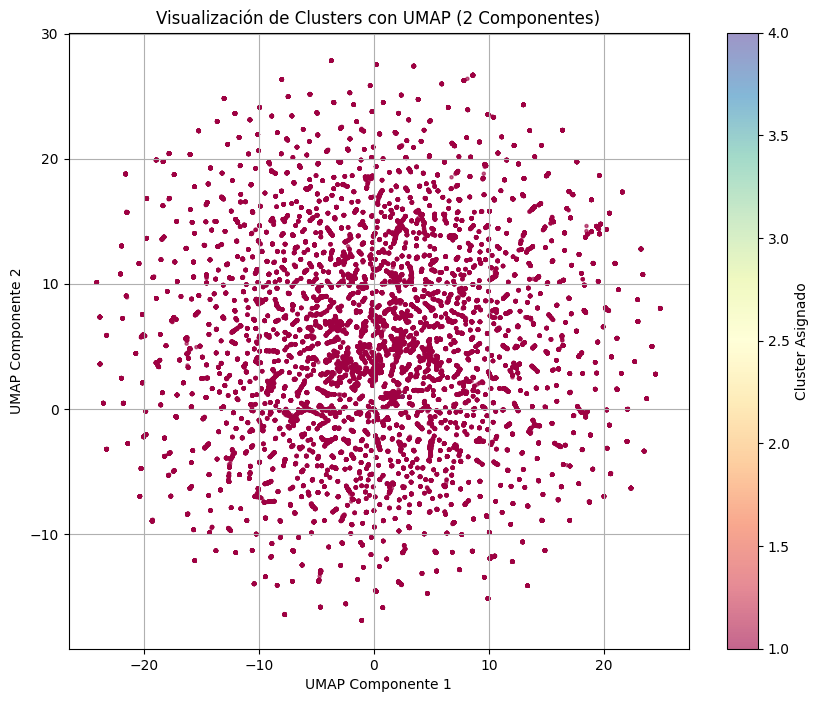

In [218]:
# prompt: Añade una visualizacion de los clisyer en 2d, asi que quiero umao de 2 componenetes

import pandas as pd
import matplotlib.pyplot as plt
# Inicializar UMAP con 2 componentes
reducer = umap.UMAP(n_components=2, random_state=42)

# Ajustar UMAP y transformar los datos
# Excluir la columna 'CLUSTER_ASIGNADO' para la reducción de dimensionalidad
embedding = reducer.fit_transform(X)

# Crear un DataFrame con los resultados de UMAP y los clusters
df_umap = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
df_umap['CLUSTER_ASIGNADO'] = y.values

# Visualizar los clusters en 2D
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_umap['UMAP_1'],
    df_umap['UMAP_2'],
    c=df_umap['CLUSTER_ASIGNADO'],
    cmap='Spectral',
    s=5,
    alpha=0.6
)
plt.colorbar(scatter, label='Cluster Asignado')
plt.title('Visualización de Clusters con UMAP (2 Componentes)')
plt.xlabel('UMAP Componente 1')
plt.ylabel('UMAP Componente 2')
plt.grid(True)
plt.show()

In [219]:
# cantidad de registros por cluster

print(unified_df_pandas['CLUSTER_ASIGNADO'].value_counts())

CLUSTER_ASIGNADO
1    49977
4       12
3        8
2        3
Name: count, dtype: Int64
